<a href="https://colab.research.google.com/github/betulbilhan2/ai-carbon-tracker/blob/main/NB5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

base_path = '/content/drive/MyDrive/terkentech'
print("Drive bağlantısı başarılı!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive bağlantısı başarılı!


In [ ]:
train_df = pd.read_parquet(f'{base_path}/01_processed/tabnet_train.parquet')
val_df = pd.read_parquet(f'{base_path}/01_processed/tabnet_val.parquet')
test_df = pd.read_parquet(f'{base_path}/01_processed/tabnet_test.parquet')

df_full = pd.concat([train_df, val_df, test_df], ignore_index=True)

drop_cols = [c for c in ['Body Type', 'Sex', 'CarbonEmission'] if c in df_full.columns]
X_cluster = df_full.drop(columns=drop_cols, errors='ignore')

print(f"Kümeleme veri seti boyutu: {X_cluster.shape}")

Kümeleme veri seti boyutu: (10000, 17)


In [ ]:
if 'Recycling' in X_cluster.columns:
    rec = X_cluster['Recycling'].astype(int).values
    X_cluster['recycles_paper'] = (rec & 1)
    X_cluster['recycles_plastic'] = ((rec & 2) >> 1)
    X_cluster['recycles_glass'] = ((rec & 4) >> 2)
    X_cluster['recycles_metal'] = ((rec & 8) >> 3)
    X_cluster = X_cluster.drop(columns=['Recycling'])

cat_cols = X_cluster.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [c for c in X_cluster.columns if c not in cat_cols]

X_encoded = pd.get_dummies(X_cluster, columns=cat_cols, drop_first=True)
scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

print(f"Ön işlenmiş matris boyutu: {X_encoded.shape}")

Ön işlenmiş matris boyutu: (10000, 20)


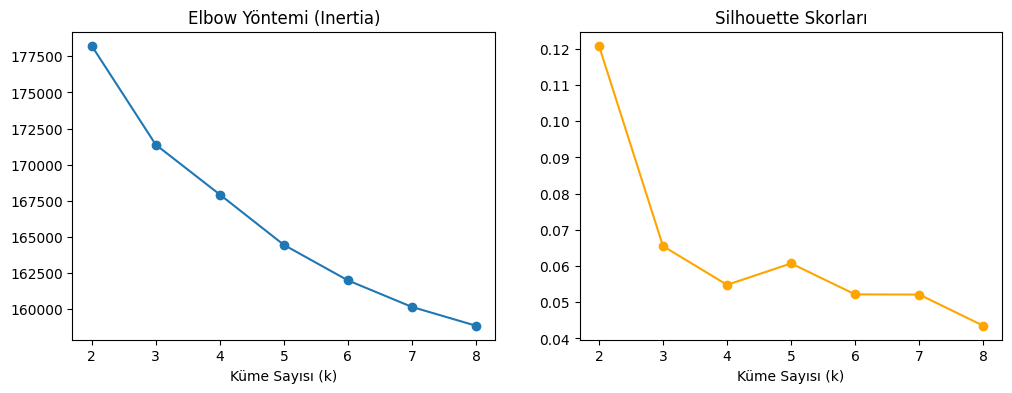

In [ ]:
inertia = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_encoded)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_encoded, labels))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Yöntemi (Inertia)')
plt.xlabel('Küme Sayısı (k)')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Skorları')
plt.xlabel('Küme Sayısı (k)')
plt.show()

In [ ]:
# Grafiğe göre en yüksek silhouette skorunu veren k = 2 değerini seçiyoruz
optimal_k = 2

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_encoded)

df_full['cluster_id'] = cluster_labels

# Modeli ve küme profillerini doğrudan Drive'daki 05_models klasörüne kaydedelim
os.makedirs(f'{base_path}/05_models', exist_ok=True)
joblib.dump(kmeans_final, f'{base_path}/05_models/kmeans_model_v1.pkl')

cluster_profiles = df_full.groupby('cluster_id').mean(numeric_only=True)
cluster_profiles.to_csv(f'{base_path}/05_models/cluster_profiles_v1.csv')

print(f"KMeans modeli (k={optimal_k}) başarıyla eğitildi ve '05_models' klasörüne kaydedildi! 🚀")
display(cluster_profiles)

KMeans modeli (k=2) başarıyla eğitildi ve '05_models' klasörüne kaydedildi! 🚀


,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
cluster_id,,,,,,,,,,,,,,,,,,,,
0,1.503425,0.500311,1.477273,1.512453,1.467621,0.000000,3.06538,0.995953,174.392279,1.513699,4420.489181,1.491594,3.994707,12.041407,25.218244,11.879203,1.030822,7.562578,7.563200,2997.512453
1,1.512227,0.498821,1.498821,1.484826,1.495433,1.494991,0.00987,0.982616,173.630524,1.498379,527.036093,1.507513,4.038745,12.185474,25.057307,11.893783,0.999411,7.532410,7.491308,1924.493665
